# House Price Prediction Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle

## 1. Load Dataset

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Combine alternating rows
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

df = pd.DataFrame(data, columns=feature_names)
df['price'] = target
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## 2. Data Cleaning and EDA

In [3]:
# Dataset shape
print("Shape:", df.shape)

# Check for missing values
print("Null counts:")
print(df.isnull().sum())

Shape: (506, 14)
Null counts:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
price      0
dtype: int64


In [4]:
# Summary statistics
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


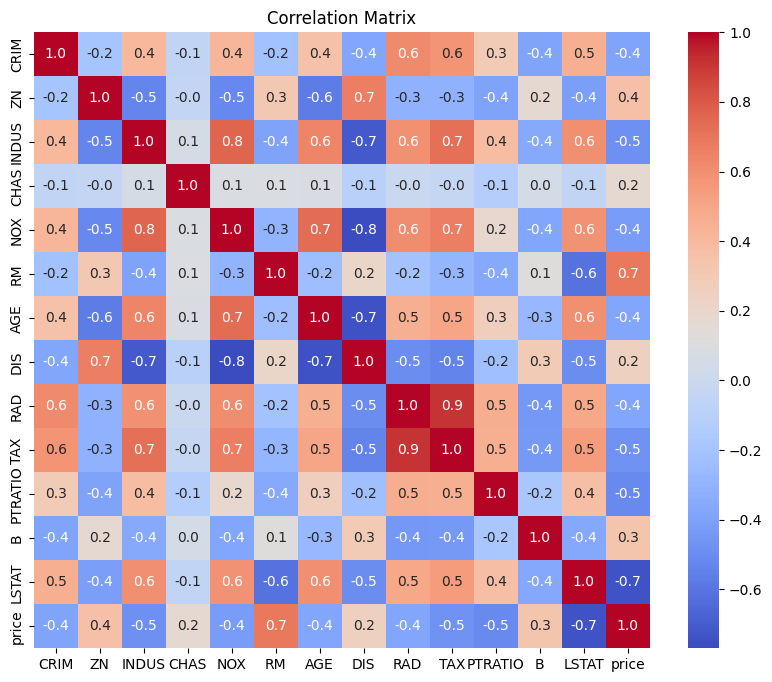

In [5]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

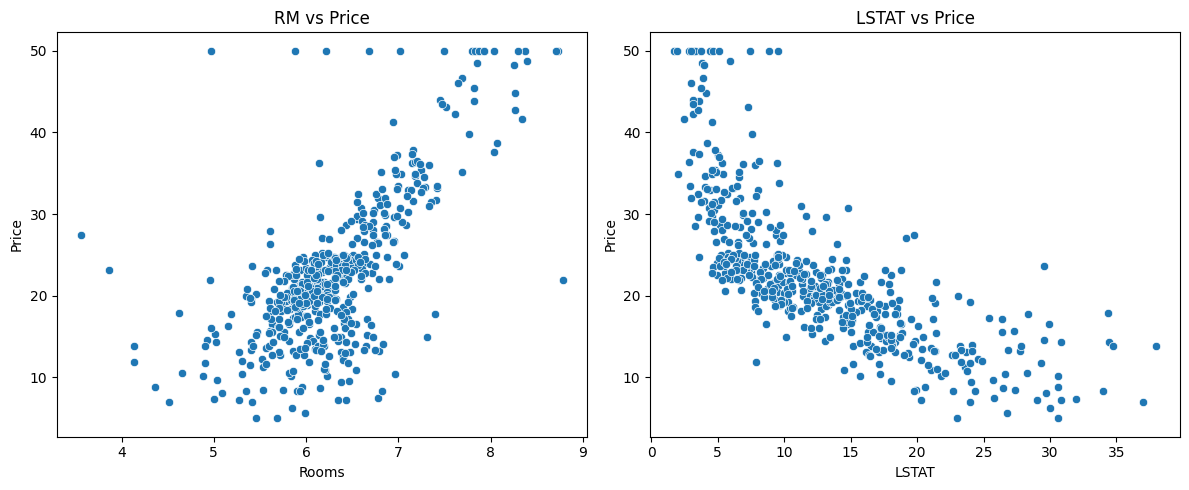

In [6]:
# RM vs Price and LSTAT vs Price scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df['RM'], y=df['price'])
plt.title('RM vs Price')
plt.xlabel('Rooms')
plt.ylabel('Price')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['LSTAT'], y=df['price'])
plt.title('LSTAT vs Price')
plt.xlabel('LSTAT')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

## 3. Split Dataset

In [7]:
X = df.drop(columns=['price'])
Y = df['price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)


## 4. Model Training

In [8]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 5. Model Evaluation and Coefficients

In [9]:
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_rmse = np.sqrt(metrics.mean_squared_error(Y_train, train_preds))
test_rmse = np.sqrt(metrics.mean_squared_error(Y_test, test_preds))

train_r2 = metrics.r2_score(Y_train, train_preds)
test_r2 = metrics.r2_score(Y_test, test_preds)

print("--- Train Metrics ---")
print(f"RMSE: {train_rmse:.3f}")
print(f"R2 Score: {train_r2:.3f}")

print("\n--- Test Metrics ---")
print(f"RMSE: {test_rmse:.3f}")
print(f"R2 Score: {test_r2:.3f}")

--- Train Metrics ---
RMSE: 4.791
R2 Score: 0.729

--- Test Metrics ---
RMSE: 4.301
R2 Score: 0.779


In [10]:
print("Intercept:", model.intercept_)

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df.sort_values(by='Coefficient', ascending=False)

Intercept: 37.19980774264961


,Coefficient
RM,3.632885
CHAS,3.158979
RAD,0.324066
ZN,0.038904
B,0.011613
AGE,0.009351
TAX,-0.011625
INDUS,-0.015152
CRIM,-0.108224
LSTAT,-0.558409


## 6. Save Model and Inference

In [11]:
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [12]:
with open('linear_regression_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

sample_house = np.array([[0.006, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296.0, 15.3, 396.9, 4.98]])
pred = loaded_model.predict(sample_house)
print(f"Predicted Price: ${pred[0]:.2f}k (${pred[0]*1000:,.2f})")

Predicted Price: $30.62k ($30,621.73)


c:\Users\Yassin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
